# Tarea 2 — Introducción a la Computación Paralela
## Procesamiento de imágenes en CUDA (matriz de covarianza)
Joaquín Ávalos y Juan Silva — Ingeniería Civil Informática

En este notebook se compilan y ejecutan las dos versiones del trabajo sobre la GPU de Colab (Tesla T4):

- **Experimento 1:** versión tradicional en CUDA (copia síncrona y covarianza con *tiling* en memoria compartida).
- **Experimento 2:** versión con CUDA Streams (memoria *pinned* + copias asíncronas y acumulación incremental), que se evalúo en dos regímenes: *compute-bound* y *transfer-bound*.

Se trabaja con GPU T4.

## 1. Verificar GPU y compilador

In [1]:
!nvidia-smi
!nvcc --version

Mon Jun 22 04:45:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Dependencias de CImg + header
`CImg.h` es *header-only*; solo hace falta `libpng`/`libjpeg` para leer PNG/JPEG.

In [2]:
!apt-get -qq install -y libpng-dev libjpeg-dev zlib1g-dev
!wget -q https://raw.githubusercontent.com/GreycLab/CImg/master/CImg.h
!ls -la CImg.h

-rw-r--r-- 1 root root 3497927 Jun 22 04:45 CImg.h


## 3. Dataset DIV2K (validación, LR bicubic ×4)
100 imágenes PNG a color. Se descomprime en `DIV2K_valid_LR_bicubic/X4/`.

In [3]:
!wget -q https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_LR_bicubic_X4.zip
!unzip -q -o DIV2K_valid_LR_bicubic_X4.zip
DATA_DIR = "DIV2K_valid_LR_bicubic/X4"
print("Imágenes encontradas:")
!ls {DATA_DIR} | wc -l
!ls {DATA_DIR} | head -3

Imágenes encontradas:
100
0801x4.png
0802x4.png
0803x4.png


## 4. Código fuente — Experimento 1
Escribo `experimento1.cu` a disco para compilarlo en la siguiente sección.

In [4]:
%%writefile experimento1.cu
// =============================================================================
//  Tarea 2 - Introduccion a la Computacion Paralela
//  Experimento 1: implementacion tradicional en CUDA.
//
//  En esta version asumo que todo el dataset entra contiguo en la memoria de la
//  GPU, asi que cargo todo de una con el stream por defecto. Para calcular la
//  matriz de covarianza C (n x n) sigo tres pasos: primero el vector promedio,
//  despues centro los datos restandole ese promedio, y por ultimo hago la
//  multiplicacion matricial Vbar^T * Vbar con tiling en memoria compartida.
//  Mido por separado la copia H2D, el computo de los kernels y la copia D2H de C
//  para ver donde se va realmente el tiempo.
//
//  Compilar:  nvcc -O3 -o exp1 experimento1.cu -lpng -ljpeg -lz -lpthread -I.
//  Ejecutar:  ./exp1 <directorio_imagenes> [maxImagenes]
// =============================================================================

#define cimg_display 0       // no uso la parte grafica de CImg
#define cimg_use_png         // para poder leer los PNG (enlazo -lpng -lz)
#define cimg_use_jpeg        // por si alguna imagen viene en JPEG (-ljpeg)
#include "CImg.h"

#include <cuda_runtime.h>
#include <cstdio>
#include <cstdlib>
#include <string>
#include <vector>
#include <algorithm>
#include <dirent.h>

using namespace cimg_library;

// Trabajo con imagenes de 128x128 en gris. Elegi este tamano porque deja n=16384
// y la matriz C ocupa n*n*4 ~= 1.07 GB, que entra comodo en los 16 GB de la T4
// (con 256x256 ya no cabria).
static const int W = 128;          // ancho objetivo
static const int H = 128;          // alto objetivo
static const int N = W * H;        // n = cantidad de componentes por imagen
#define TILE 16                    // lado del bloque de tiling (16x16 = 256 hilos)

// Macro para chequear el retorno de cada llamada CUDA sin repetir el if a mano.
#define CHECK(call) do {                                                   \
    cudaError_t _e = (call);                                               \
    if (_e != cudaSuccess) {                                               \
        fprintf(stderr, "CUDA error %s:%d -> %s\n", __FILE__, __LINE__,    \
                cudaGetErrorString(_e));                                   \
        exit(EXIT_FAILURE);                                                \
    }                                                                      \
} while (0)

// Lista los .png del directorio. Los ordeno por nombre para que la carga sea
// siempre la misma y los resultados sean reproducibles entre corridas.
static std::vector<std::string> listPng(const std::string& dir) {
    std::vector<std::string> files;
    DIR* dp = opendir(dir.c_str());
    if (!dp) { fprintf(stderr, "No se pudo abrir el directorio: %s\n", dir.c_str()); exit(1); }
    struct dirent* ep;
    while ((ep = readdir(dp)) != nullptr) {
        std::string name = ep->d_name;
        if (name.size() > 4 && name.substr(name.size() - 4) == ".png")
            files.push_back(dir + "/" + name);
    }
    closedir(dp);
    std::sort(files.begin(), files.end());
    return files;
}

// Carga las imagenes ya aplanadas en h_data (m filas de N valores). Como las
// imagenes de DIV2K tienen tamanos distintos, las redimensiono todas a W x H
// para poder armar una matriz uniforme. Devuelve cuantas alcance a cargar.
static int loadDataset(const std::string& dir, int maxImages, float* h_data) {
    std::vector<std::string> files = listPng(dir);
    int m = std::min((int)files.size(), maxImages);
    if (m == 0) { fprintf(stderr, "No se encontraron .png en %s\n", dir.c_str()); exit(1); }

    for (int k = 0; k < m; k++) {
        CImg<unsigned char> img(files[k].c_str());
        img.resize(W, H, 1, img.spectrum(), 3);          // 3 = interpolacion lineal
        float* row = h_data + (size_t)k * N;
        if (img.spectrum() >= 3) {                       // si es color, paso a gris
            cimg_forXY(img, x, y) {                      // con la luminancia estandar
                float r = img(x, y, 0, 0), g = img(x, y, 0, 1), b = img(x, y, 0, 2);
                row[y * W + x] = 0.299f * r + 0.587f * g + 0.114f * b;
            }
        } else {                                         // si ya viene en gris, la copio
            cimg_forXY(img, x, y) row[y * W + x] = (float)img(x, y, 0, 0);
        }
    }
    return m;
}

// Kernel 1 - vector promedio. Pongo un hilo por componente j y ese hilo recorre
// las m imagenes sumando. Asi hilos vecinos (j, j+1) leen posiciones contiguas
// data[k*N+j], que es justo lo que necesito para que los accesos sean coalescentes.
__global__ void meanKernel(const float* __restrict__ data, float* __restrict__ mean,
                           int m, int n) {
    int j = blockIdx.x * blockDim.x + threadIdx.x;
    if (j >= n) return;
    float s = 0.0f;
    for (int k = 0; k < m; k++) s += data[(size_t)k * n + j];
    mean[j] = s / m;
}

// Kernel 2 - centrado. Le resto el promedio a cada imagen sobre el mismo arreglo
// (in-place) para no gastar memoria extra. Uso un grid 2D recorriendo (componente, imagen).
__global__ void centerKernel(float* __restrict__ data, const float* __restrict__ mean,
                             int m, int n) {
    int j = blockIdx.x * blockDim.x + threadIdx.x;   // componente
    int k = blockIdx.y * blockDim.y + threadIdx.y;   // imagen
    if (j >= n || k >= m) return;
    data[(size_t)k * n + j] -= mean[j];
}

// Kernel 3 - covarianza con tiling. Lo que necesito es C = (1/m) * Vbar^T * Vbar,
// que es una multiplicacion de matrices donde la dimension interna es k (las m
// imagenes). En vez de leer la memoria global una y otra vez, cada bloque carga
// un "tile" de la entrada en memoria compartida y lo reutiliza entre sus hilos,
// que es lo que de verdad acelera el producto. As guarda un tile de Vbar^T y Bs
// uno de Vbar; cada hilo acumula un elemento C[row][col].
__global__ void covTiledKernel(const float* __restrict__ V, float* __restrict__ C,
                               int m, int n) {
    __shared__ float As[TILE][TILE];   // As[ty][tx] = V[k][row]  (viene de Vbar^T)
    __shared__ float Bs[TILE][TILE];   // Bs[ty][tx] = V[k][col]  (viene de Vbar)

    int ty = threadIdx.y, tx = threadIdx.x;
    int row = blockIdx.y * TILE + ty;  // fila de salida (componente i)
    int col = blockIdx.x * TILE + tx;  // columna de salida (componente j)

    float acc = 0.0f;
    int numTiles = (m + TILE - 1) / TILE;
    for (int t = 0; t < numTiles; t++) {
        int kA = t * TILE + tx;        // indice k que carga este hilo en As
        int kB = t * TILE + ty;        // indice k que carga este hilo en Bs
        // Si me paso del borde (m no es multiplo de TILE) cargo 0 para no sumar basura.
        As[ty][tx] = (row < n && kA < m) ? V[(size_t)kA * n + row] : 0.0f;
        Bs[ty][tx] = (col < n && kB < m) ? V[(size_t)kB * n + col] : 0.0f;
        __syncthreads();               // espero a que el tile este completo
        #pragma unroll
        for (int e = 0; e < TILE; e++) acc += As[ty][e] * Bs[e][tx];
        __syncthreads();               // espero antes de pisar el tile en la siguiente vuelta
    }
    if (row < n && col < n) C[(size_t)row * n + col] = acc / m;
}

// =============================================================================
int main(int argc, char** argv) {
    std::string dir = (argc > 1) ? argv[1] : "DIV2K_valid_LR_bicubic/X4";
    int maxImages   = (argc > 2) ? atoi(argv[2]) : 100;

    // Aca uso memoria normal (paginada) a proposito: esta version hace la copia
    // sincronica, no necesito memoria anclada todavia (eso lo dejo para el Exp 2).
    float* h_data = (float*)malloc((size_t)maxImages * N * sizeof(float));
    int m = loadDataset(dir, maxImages, h_data);
    printf("[Exp1] m=%d imagenes, n=%d, matriz C = %dx%d (%.2f GB)\n",
           m, N, N, N, (double)N * N * sizeof(float) / 1e9);

    // Reservo en la GPU: el dataset, el vector promedio y la matriz de covarianza.
    float *d_data, *d_mean, *d_cov;
    CHECK(cudaMalloc(&d_data, (size_t)m * N * sizeof(float)));
    CHECK(cudaMalloc(&d_mean, (size_t)N * sizeof(float)));
    CHECK(cudaMalloc(&d_cov,  (size_t)N * N * sizeof(float)));

    // Uso eventos CUDA para cronometrar cada etapa por separado.
    cudaEvent_t e0, e1, e2, e3;
    CHECK(cudaEventCreate(&e0)); CHECK(cudaEventCreate(&e1));
    CHECK(cudaEventCreate(&e2)); CHECK(cudaEventCreate(&e3));

    // (a) Copia del dataset hacia la GPU, sincronica.
    CHECK(cudaEventRecord(e0));
    CHECK(cudaMemcpy(d_data, h_data, (size_t)m * N * sizeof(float), cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(e1));

    // (b) Los tres kernels en orden: promedio, centrado y covarianza.
    int blk = 256;
    meanKernel<<<(N + blk - 1) / blk, blk>>>(d_data, d_mean, m, N);

    dim3 cBlock(64, 4);
    dim3 cGrid((N + cBlock.x - 1) / cBlock.x, (m + cBlock.y - 1) / cBlock.y);
    centerKernel<<<cGrid, cBlock>>>(d_data, d_mean, m, N);

    dim3 tBlock(TILE, TILE);
    dim3 tGrid((N + TILE - 1) / TILE, (N + TILE - 1) / TILE);
    covTiledKernel<<<tGrid, tBlock>>>(d_data, d_cov, m, N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(e2));

    // (c) Devuelvo la matriz C al host. Ojo que C es lo mas pesado (1 GB), asi que
    //     espero que esta copia sea la mas lenta de las tres.
    float* h_cov = (float*)malloc((size_t)N * N * sizeof(float));
    CHECK(cudaMemcpy(h_cov, d_cov, (size_t)N * N * sizeof(float), cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(e3));
    CHECK(cudaEventSynchronize(e3));

    float tH2D, tCompute, tD2H;
    CHECK(cudaEventElapsedTime(&tH2D,     e0, e1));
    CHECK(cudaEventElapsedTime(&tCompute, e1, e2));
    CHECK(cudaEventElapsedTime(&tD2H,     e2, e3));
    printf("[Exp1] Copia H2D dataset : %8.3f ms\n", tH2D);
    printf("[Exp1] Computo kernels   : %8.3f ms\n", tCompute);
    printf("[Exp1] Copia D2H matriz C: %8.3f ms\n", tD2H);
    printf("[Exp1] TOTAL             : %8.3f ms\n", tH2D + tCompute + tD2H);

    // Para verificar que el resultado esta bien saco la traza y la suma total.
    // Acumulo en double porque sumar millones de floats pierde precision si no.
    // Estos mismos numeros me sirven para comparar contra el Experimento 2.
    double trace = 0.0, checksum = 0.0;
    for (int i = 0; i < N; i++) trace += h_cov[(size_t)i * N + i];
    for (size_t i = 0; i < (size_t)N * N; i++) checksum += h_cov[i];
    printf("[Exp1] traza(C)=%.6e  C[0][0]=%.6f  C[0][1]=%.6f  checksum=%.6e\n",
           trace, h_cov[0], h_cov[1], checksum);

    free(h_data); free(h_cov);
    cudaFree(d_data); cudaFree(d_mean); cudaFree(d_cov);
    cudaEventDestroy(e0); cudaEventDestroy(e1);
    cudaEventDestroy(e2); cudaEventDestroy(e3);
    return 0;
}


Writing experimento1.cu


## 5. Código fuente — Experimento 2

In [5]:
%%writefile experimento2.cu
// =============================================================================
//  Tarea 2 - Introduccion a la Computacion Paralela
//  Experimento 2: version optimizada con CUDA Streams (pinned memory + async).
//
//  La idea es no cargar todo de golpe sino partir las imagenes en batches y
//  procesarlas en varios streams a la vez, para que mientras la GPU calcula un
//  batch, se vaya copiando el siguiente. El detalle es que para centrar necesito
//  el promedio de TODO el conjunto, lo que obligaria a una pasada extra. Para
//  evitarlo, en vez de centrar, desarrollo la covarianza con esta identidad:
//
//     C = (1/m) sum_k (v-mu)(v-mu)^T = (1/m) sum_k v v^T  -  mu mu^T
//
//  De esta forma cada batch puede aportar por su cuenta dos sumas parciales:
//     - sum de v       -> para el promedio mu      (meanSumKernel)
//     - sum de v v^T    -> momento de 2do orden     (covAccumKernel, con atomicAdd)
//  y recien al final aplico la correccion -mu mu^T (finalizeKernel). Como la suma
//  es asociativa, da exactamente la misma C que el Experimento 1, asi que comparo
//  la traza y el checksum de ambos para asegurarme de que esta bien.
//
//  Para poder estudiar bien el efecto de los streams dejo dos modos:
//     - mode=resize : una muestra por imagen redimensionada a P x P. Con P=128 el
//                     computo manda y la transferencia es despreciable (compute-bound).
//     - mode=patch  : troceo cada imagen en parches P x P y junto muchas muestras.
//                     Con P=32 y miles de parches la copia ya pesa (transfer-bound).
//
//  Compilar:  nvcc -O3 -o exp2 experimento2.cu -lpng -ljpeg -lz -lpthread -I.
//  Ejecutar:  ./exp2 <dir> <numMuestras> <S> <batchSize> [P=128] [mode=resize|patch]
//                    [reps=3] [timelineCSV]
//    compute-bound :  ./exp2 DIV2K_valid_LR_bicubic/X4 100   8 10  128 resize 3
//    transfer-bound:  ./exp2 DIV2K_valid_LR_bicubic/X4 15000 8 100 32  patch  3
//    timeline      :  ./exp2 DIV2K_valid_LR_bicubic/X4 2000  8 100 32  patch  1 tl.csv
// =============================================================================

#define cimg_display 0
#define cimg_use_png
#define cimg_use_jpeg
#include "CImg.h"

#include <cuda_runtime.h>
#include <cstdio>
#include <cstdlib>
#include <cstring>
#include <string>
#include <vector>
#include <algorithm>
#include <dirent.h>

using namespace cimg_library;

#define TILE 16

#define CHECK(call) do {                                                   \
    cudaError_t _e = (call);                                               \
    if (_e != cudaSuccess) {                                               \
        fprintf(stderr, "CUDA error %s:%d -> %s\n", __FILE__, __LINE__,    \
                cudaGetErrorString(_e));                                   \
        exit(EXIT_FAILURE);                                                \
    }                                                                      \
} while (0)

// ----------------------------- Lectura de imagenes ---------------------------
// Mismo listado ordenado que en el Exp 1 para tener corridas reproducibles.
static std::vector<std::string> listPng(const std::string& dir) {
    std::vector<std::string> files;
    DIR* dp = opendir(dir.c_str());
    if (!dp) { fprintf(stderr, "No se pudo abrir el directorio: %s\n", dir.c_str()); exit(1); }
    struct dirent* ep;
    while ((ep = readdir(dp)) != nullptr) {
        std::string name = ep->d_name;
        if (name.size() > 4 && name.substr(name.size() - 4) == ".png")
            files.push_back(dir + "/" + name);
    }
    closedir(dp);
    std::sort(files.begin(), files.end());
    return files;
}

// Paso una imagen a gris (luminancia). La saco a una funcion aparte porque la
// reuso en los dos modos de carga.
static void toGray(const CImg<unsigned char>& img, std::vector<float>& gray) {
    int wi = img.width(), hi = img.height();
    gray.resize((size_t)wi * hi);
    if (img.spectrum() >= 3) {
        cimg_forXY(img, x, y)
            gray[(size_t)y * wi + x] = 0.299f * img(x, y, 0, 0)
                                     + 0.587f * img(x, y, 0, 1)
                                     + 0.114f * img(x, y, 0, 2);
    } else {
        cimg_forXY(img, x, y) gray[(size_t)y * wi + x] = (float)img(x, y, 0, 0);
    }
}

// Modo resize: igual que el Exp 1, una muestra por imagen llevada a P x P.
static int loadResize(const std::string& dir, int maxSamples, int P, float* h_data) {
    std::vector<std::string> files = listPng(dir);
    int m = std::min((int)files.size(), maxSamples);
    if (m == 0) { fprintf(stderr, "No se encontraron .png en %s\n", dir.c_str()); exit(1); }
    int n = P * P;
    std::vector<float> gray;
    for (int k = 0; k < m; k++) {
        CImg<unsigned char> img(files[k].c_str());
        img.resize(P, P, 1, img.spectrum(), 3);
        toGray(img, gray);
        memcpy(h_data + (size_t)k * n, gray.data(), (size_t)n * sizeof(float));
    }
    return m;
}

// Modo patch: en vez de una muestra por imagen, troceo cada imagen en parches
// P x P sin solapar. Asi consigo miles de muestras chicas a partir de las 100
// imagenes, que es lo que necesito para llevar el problema al caso transfer-bound.
static int loadPatches(const std::string& dir, int maxSamples, int P, float* h_data) {
    std::vector<std::string> files = listPng(dir);
    if (files.empty()) { fprintf(stderr, "No se encontraron .png en %s\n", dir.c_str()); exit(1); }
    int n = P * P;
    int collected = 0;
    std::vector<float> gray;
    for (size_t f = 0; f < files.size() && collected < maxSamples; f++) {
        CImg<unsigned char> img(files[f].c_str());
        int wi = img.width(), hi = img.height();
        toGray(img, gray);
        for (int py = 0; py + P <= hi && collected < maxSamples; py += P) {
            for (int px = 0; px + P <= wi && collected < maxSamples; px += P) {
                float* row = h_data + (size_t)collected * n;
                for (int yy = 0; yy < P; yy++)
                    for (int xx = 0; xx < P; xx++)
                        row[yy * P + xx] = gray[(size_t)(py + yy) * wi + (px + xx)];
                collected++;
            }
        }
    }
    if (collected == 0) { fprintf(stderr, "Imagenes mas chicas que P=%d\n", P); exit(1); }
    return collected;
}

// ------------------------------- Kernels -------------------------------------

// Suma parcial del promedio: cada hilo suma su componente j sobre las imagenes
// del batch. Como distintos streams escriben sobre el mismo meanSum a la vez,
// uso atomicAdd para que no se pisen.
__global__ void meanSumKernel(const float* __restrict__ V, float* __restrict__ meanSum,
                              int bs, int n) {
    int j = blockIdx.x * blockDim.x + threadIdx.x;
    if (j >= n) return;
    float s = 0.0f;
    for (int k = 0; k < bs; k++) s += V[(size_t)k * n + j];
    atomicAdd(&meanSum[j], s);
}

// Aporte de un batch a la covarianza: calcula V_batch^T * V_batch con el mismo
// tiling del Exp 1, pero como cada batch suma su parte a la C global y pueden
// estar corriendo varios streams en paralelo, el resultado lo acumulo con atomicAdd.
__global__ void covAccumKernel(const float* __restrict__ V, float* __restrict__ C,
                               int bs, int n) {
    __shared__ float As[TILE][TILE];
    __shared__ float Bs[TILE][TILE];
    int ty = threadIdx.y, tx = threadIdx.x;
    int row = blockIdx.y * TILE + ty;
    int col = blockIdx.x * TILE + tx;
    float acc = 0.0f;
    int numTiles = (bs + TILE - 1) / TILE;
    for (int t = 0; t < numTiles; t++) {
        int kA = t * TILE + tx;
        int kB = t * TILE + ty;
        As[ty][tx] = (row < n && kA < bs) ? V[(size_t)kA * n + row] : 0.0f;
        Bs[ty][tx] = (col < n && kB < bs) ? V[(size_t)kB * n + col] : 0.0f;
        __syncthreads();
        #pragma unroll
        for (int e = 0; e < TILE; e++) acc += As[ty][e] * Bs[e][tx];
        __syncthreads();
    }
    if (row < n && col < n) atomicAdd(&C[(size_t)row * n + col], acc);
}

// Paso final: aplico la correccion de la identidad. Lo que tengo acumulado en C
// es sum(v v^T), asi que divido por m y le resto mu*mu^T para obtener la covarianza.
__global__ void finalizeKernel(float* __restrict__ C, const float* __restrict__ meanSum,
                               int m, int n) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (row >= n || col >= n) return;
    float mui = meanSum[row] / m;
    float muj = meanSum[col] / m;
    C[(size_t)row * n + col] = C[(size_t)row * n + col] / m - mui * muj;
}

// =============================================================================
int main(int argc, char** argv) {
    std::string dir = (argc > 1) ? argv[1] : "DIV2K_valid_LR_bicubic/X4";
    int maxSamples  = (argc > 2) ? atoi(argv[2]) : 100;
    int S           = (argc > 3) ? atoi(argv[3]) : 1;            // cantidad de streams
    int batchSize   = (argc > 4) ? atoi(argv[4]) : 10;           // imagenes por batch
    int P           = (argc > 5) ? atoi(argv[5]) : 128;          // lado de imagen/parche
    std::string mode = (argc > 6) ? argv[6] : "resize";          // "resize" o "patch"
    int reps        = (argc > 7) ? atoi(argv[7]) : 3;            // repeticiones para promediar
    std::string tlFile = (argc > 8) ? argv[8] : "";              // si lo paso, vuelco el timeline
    if (S < 1) S = 1;
    int n = P * P;
    bool timeline = !tlFile.empty();
    if (timeline) reps = 1;             // para el timeline me basta una corrida

    // Memoria del host ANCLADA (pinned). Es indispensable: solo con pinned el
    // cudaMemcpyAsync puede solaparse de verdad con el computo de otro stream.
    float* h_data;
    CHECK(cudaMallocHost(&h_data, (size_t)maxSamples * n * sizeof(float)));
    int m = (mode == "patch") ? loadPatches(dir, maxSamples, P, h_data)
                              : loadResize(dir, maxSamples, P, h_data);
    int numBatches = (m + batchSize - 1) / batchSize;
    printf("[Exp2] modo=%s  m=%d  P=%d (n=%d)  S=%d  batch=%d  (%d batches)  "
           "C=%.4f GB  dataset=%.4f GB\n",
           mode.c_str(), m, P, n, S, batchSize, numBatches,
           (double)n * n * sizeof(float) / 1e9,
           (double)m * n * sizeof(float) / 1e9);

    // C y el acumulador del promedio viven en la GPU todo el rato; los batches van
    // entrando por encima. Notar que aca solo guardo C (n x n) y S buffers chicos,
    // nunca el dataset entero, asi que esto escala aunque haya muchisimas muestras.
    float *d_cov, *d_meanSum;
    CHECK(cudaMalloc(&d_cov,     (size_t)n * n * sizeof(float)));
    CHECK(cudaMalloc(&d_meanSum, (size_t)n * sizeof(float)));

    // Un buffer y un stream por cada stream logico. Reusar el buffer del stream s
    // entre sus batches es seguro porque dentro de un stream todo va en orden.
    std::vector<float*>       d_batch(S);
    std::vector<cudaStream_t> stream(S);
    for (int s = 0; s < S; s++) {
        CHECK(cudaMalloc(&d_batch[s], (size_t)batchSize * n * sizeof(float)));
        CHECK(cudaStreamCreate(&stream[s]));
    }

    cudaEvent_t eStart, eEnd;
    CHECK(cudaEventCreate(&eStart)); CHECK(cudaEventCreate(&eEnd));

    // Si pido timeline, creo eventos por batch para marcar inicio/fin de copia y
    // fin de computo, y despues reconstruyo el diagrama de Gantt con esos tiempos.
    std::vector<cudaEvent_t> evCopyIni, evCopyFin, evCompFin;
    if (timeline) {
        evCopyIni.resize(numBatches); evCopyFin.resize(numBatches); evCompFin.resize(numBatches);
        for (int b = 0; b < numBatches; b++) {
            CHECK(cudaEventCreate(&evCopyIni[b]));
            CHECK(cudaEventCreate(&evCopyFin[b]));
            CHECK(cudaEventCreate(&evCompFin[b]));
        }
    }

    dim3 tBlock(TILE, TILE);
    dim3 tGrid((n + TILE - 1) / TILE, (n + TILE - 1) / TILE);
    int  blk = 256;

    // Repito la medicion varias veces y despues me quedo con el minimo, asi saco
    // el ruido de las primeras corridas (warm-up) y los numeros quedan estables.
    std::vector<float> tiempos;
    for (int rep = 0; rep < reps; rep++) {
        CHECK(cudaMemset(d_cov,     0, (size_t)n * n * sizeof(float)));   // arranco C en 0
        CHECK(cudaMemset(d_meanSum, 0, (size_t)n * sizeof(float)));

        CHECK(cudaEventRecord(eStart));
        // Reparto los batches entre los streams en round-robin. La gracia es que la
        // copia del batch b (stream s) se solapa con el computo del batch anterior
        // que quedo en otro stream.
        for (int b = 0; b < numBatches; b++) {
            int s   = b % S;
            int off = b * batchSize;
            int bs  = std::min(batchSize, m - off);             // el ultimo batch puede ser mas chico
            if (timeline) CHECK(cudaEventRecord(evCopyIni[b], stream[s]));
            CHECK(cudaMemcpyAsync(d_batch[s], h_data + (size_t)off * n,
                                  (size_t)bs * n * sizeof(float),
                                  cudaMemcpyHostToDevice, stream[s]));
            if (timeline) CHECK(cudaEventRecord(evCopyFin[b], stream[s]));
            meanSumKernel<<<(n + blk - 1) / blk, blk, 0, stream[s]>>>(d_batch[s], d_meanSum, bs, n);
            covAccumKernel<<<tGrid, tBlock, 0, stream[s]>>>(d_batch[s], d_cov, bs, n);
            if (timeline) CHECK(cudaEventRecord(evCompFin[b], stream[s]));
        }
        CHECK(cudaGetLastError());
        CHECK(cudaDeviceSynchronize());                         // espero a que terminen todos los streams

        dim3 fBlock(16, 16);
        dim3 fGrid((n + 15) / 16, (n + 15) / 16);
        finalizeKernel<<<fGrid, fBlock>>>(d_cov, d_meanSum, m, n);
        CHECK(cudaEventRecord(eEnd));
        CHECK(cudaEventSynchronize(eEnd));

        float ms; CHECK(cudaEventElapsedTime(&ms, eStart, eEnd));
        tiempos.push_back(ms);
    }

    // Reporto el minimo (y la mediana de referencia) sobre las repeticiones.
    std::sort(tiempos.begin(), tiempos.end());
    float tMin = tiempos.front();
    float tMed = tiempos[tiempos.size() / 2];
    printf("[Exp2] TIEMPO (S=%d) min=%.3f ms  mediana=%.3f ms  (reps=%d)\n",
           S, tMin, tMed, reps);

    // Si pedi timeline, paso los eventos a milisegundos relativos al inicio y los
    // escribo a CSV para graficar despues el solapamiento en Python.
    if (timeline) {
        FILE* f = fopen(tlFile.c_str(), "w");
        fprintf(f, "batch,stream,copy_ini_ms,copy_fin_ms,comp_fin_ms\n");
        for (int b = 0; b < numBatches; b++) {
            float ci, cf, pf;
            CHECK(cudaEventElapsedTime(&ci, eStart, evCopyIni[b]));
            CHECK(cudaEventElapsedTime(&cf, eStart, evCopyFin[b]));
            CHECK(cudaEventElapsedTime(&pf, eStart, evCompFin[b]));
            fprintf(f, "%d,%d,%.4f,%.4f,%.4f\n", b, b % S, ci, cf, pf);
        }
        fclose(f);
        printf("[Exp2] Timeline escrito en %s\n", tlFile.c_str());
    }

    // Bajo C al host y saco traza y checksum. Tienen que dar lo mismo que el Exp 1.
    float* h_cov = (float*)malloc((size_t)n * n * sizeof(float));
    CHECK(cudaMemcpy(h_cov, d_cov, (size_t)n * n * sizeof(float), cudaMemcpyDeviceToHost));
    double trace = 0.0, checksum = 0.0;
    for (int i = 0; i < n; i++) trace += h_cov[(size_t)i * n + i];
    for (size_t i = 0; i < (size_t)n * n; i++) checksum += h_cov[i];
    printf("[Exp2] traza(C)=%.6e  C[0][0]=%.6f  checksum=%.6e\n", trace, h_cov[0], checksum);

    // Libero todo.
    for (int s = 0; s < S; s++) { cudaFree(d_batch[s]); cudaStreamDestroy(stream[s]); }
    if (timeline) for (int b = 0; b < numBatches; b++) {
        cudaEventDestroy(evCopyIni[b]); cudaEventDestroy(evCopyFin[b]); cudaEventDestroy(evCompFin[b]);
    }
    free(h_cov); cudaFreeHost(h_data);
    cudaFree(d_cov); cudaFree(d_meanSum);
    cudaEventDestroy(eStart); cudaEventDestroy(eEnd);
    return 0;
}


Writing experimento2.cu


## 6. Compilar ambos programas

In [6]:
!nvcc -O3 -o exp1 experimento1.cu -lpng -ljpeg -lz -lpthread -I.
!nvcc -O3 -o exp2 experimento2.cu -lpng -ljpeg -lz -lpthread -I.
print("Compilación OK")

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Compilación OK


## 7. Experimento 1 — implementación tradicional
Mido por separado la copia H2D, el cómputo de los kernels y la copia D2H de la matriz C. La copia D2H de C (1.07 GB) termina dominando el tiempo total.

In [7]:
!./exp1 DIV2K_valid_LR_bicubic/X4 100

[Exp1] m=100 imagenes, n=16384, matriz C = 16384x16384 (1.07 GB)
[Exp1] Copia H2D dataset :    2.438 ms
[Exp1] Computo kernels   :  255.059 ms
[Exp1] Copia D2H matriz C:  695.032 ms
[Exp1] TOTAL             :  952.529 ms
[Exp1] traza(C)=6.437424e+07  C[0][0]=5082.555176  C[0][1]=4702.717285  checksum=3.315760e+11


## 8. Experimento 2 — barrido de streams en DOS regímenes

Comparamos el *speedup* de los CUDA Streams en dos situaciones:

- **Régimen A — compute-bound:** 128×128, 1 muestra por imagen (`resize`). El cómputo de la covarianza (O(n²) por muestra) domina y la transferencia es despreciable → los streams casi **no** ayudan.
- **Régimen B — transfer-bound:** 32×32, miles de parches (`patch`). La transferencia pasa a ser una fracción relevante del tiempo → los streams **sí** ocultan latencia y el speedup sube y luego satura.

Cada configuración se corre varias veces (`reps`) y se reporta el **mínimo** (menos ruido).

=== Régimen A: COMPUTE-BOUND (128x128, resize, 100 imágenes) ===
[Exp2] modo=resize  m=100  P=128 (n=16384)  S=1  batch=10  (10 batches)  C=1.0737 GB  dataset=0.0066 GB

=== Régimen B: TRANSFER-BOUND (32x32, patches, 15000 muestras) ===
[Exp2] modo=patch  m=15000  P=32 (n=1024)  S=1  batch=100  (150 batches)  C=0.0042 GB  dataset=0.0614 GB

Régimen A (compute-bound)
  S | Tiempo(ms) | Speedup
  1 |   161.605  | 1.000
  2 |   161.612  | 1.000
  4 |   162.665  | 0.993
  8 |   158.831  | 1.017
 16 |   158.554  | 1.019

Régimen B (transfer-bound)
  S | Tiempo(ms) | Speedup
  1 |    61.307  | 1.000
  2 |    50.061  | 1.225
  4 |    50.067  | 1.224
  8 |    49.724  | 1.233
 16 |    49.307  | 1.243


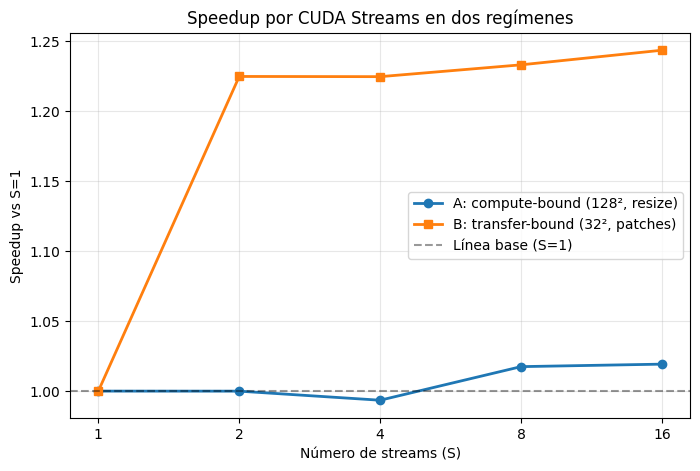

Gráfico guardado en speedup_comparacion.png


In [8]:
import subprocess, re
import matplotlib.pyplot as plt

DATA_DIR = "DIV2K_valid_LR_bicubic/X4"
streams  = [1, 2, 4, 8, 16]

def run_sweep(num, batch, P, mode, reps=3):
    t = {}
    for S in streams:
        res = subprocess.run(
            ["./exp2", DATA_DIR, str(num), str(S), str(batch), str(P), mode, str(reps)],
            capture_output=True, text=True)
        if res.returncode != 0:
            print("ERROR:", res.stderr); return None
        if S == streams[0]:
            print(res.stdout.splitlines()[0])           # config
        t[S] = float(re.search(r"min=([\d.]+)", res.stdout).group(1))
    return t

print("=== Régimen A: COMPUTE-BOUND (128x128, resize, 100 imágenes) ===")
tA = run_sweep(100,   10,  128, "resize")
print("\n=== Régimen B: TRANSFER-BOUND (32x32, patches, 15000 muestras) ===")
tB = run_sweep(15000, 100, 32,  "patch")

def tabla(t, nombre):
    base = t[streams[0]]
    print(f"\n{nombre}\n  S | Tiempo(ms) | Speedup")
    for S in streams:
        print(f"{S:3d} | {t[S]:9.3f}  | {base/t[S]:.3f}")
    return [base / t[S] for S in streams]

spA = tabla(tA, "Régimen A (compute-bound)")
spB = tabla(tB, "Régimen B (transfer-bound)")

plt.figure(figsize=(8, 5))
plt.plot(streams, spA, "o-", linewidth=2, label="A: compute-bound (128², resize)")
plt.plot(streams, spB, "s-", linewidth=2, label="B: transfer-bound (32², patches)")
plt.axhline(1.0, color="k", linestyle="--", alpha=0.4, label="Línea base (S=1)")
plt.xscale("log", base=2); plt.xticks(streams, streams)
plt.xlabel("Número de streams (S)"); plt.ylabel("Speedup vs S=1")
plt.title("Speedup por CUDA Streams en dos regímenes")
plt.grid(True, alpha=0.3); plt.legend()
plt.savefig("speedup_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en speedup_comparacion.png")

## 9. Diagrama de solapamiento (línea de tiempo con eventos CUDA)

Para evidenciar el solapamiento instrumenté `exp2` con eventos CUDA por batch (inicio y fin de
cada copia y fin de cada cómputo) y con eso dibujo un diagrama de Gantt.

Uso el régimen transfer-bound (32×32, parches) con pocas muestras para que el diagrama sea legible,
y comparo **S=1** (todo serializado en un stream) contra **S=8** (copias y cómputos solapados).

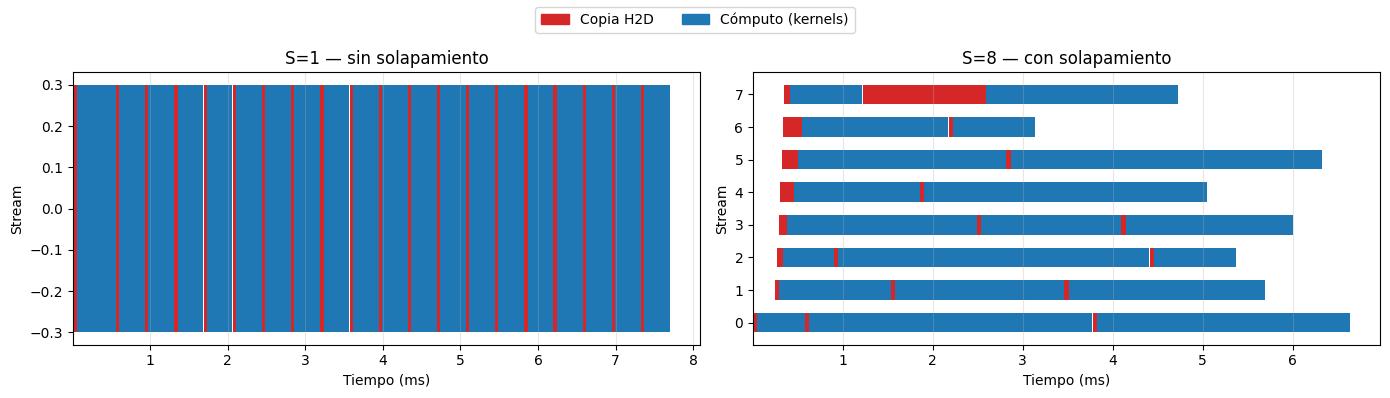

Diagrama guardado en timeline_solapamiento.png


In [9]:
import subprocess, csv
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_DIR = "DIV2K_valid_LR_bicubic/X4"

def correr_timeline(S, csvfile, num=2000, batch=100, P=32, mode="patch"):
    subprocess.run(["./exp2", DATA_DIR, str(num), str(S), str(batch),
                    str(P), mode, "1", csvfile], check=True, capture_output=True, text=True)
    with open(csvfile) as fh:
        return list(csv.DictReader(fh))

def dibujar(ax, filas, titulo):
    for r in filas:
        s  = int(r["stream"])
        ci = float(r["copy_ini_ms"]); cf = float(r["copy_fin_ms"]); pf = float(r["comp_fin_ms"])
        ax.barh(s, cf - ci, left=ci, color="#d62728", height=0.6)   # copia H2D
        ax.barh(s, pf - cf, left=cf, color="#1f77b4", height=0.6)   # cómputo
    ax.set_xlabel("Tiempo (ms)"); ax.set_ylabel("Stream"); ax.set_title(titulo)
    ax.grid(True, axis="x", alpha=0.3)

filas_S1 = correr_timeline(1, "tl_S1.csv")
filas_S8 = correr_timeline(8, "tl_S8.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dibujar(axes[0], filas_S1, "S=1 — sin solapamiento")
dibujar(axes[1], filas_S8, "S=8 — con solapamiento")
leg = [mpatches.Patch(color="#d62728", label="Copia H2D"),
       mpatches.Patch(color="#1f77b4", label="Cómputo (kernels)")]
fig.legend(handles=leg, loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("timeline_solapamiento.png", dpi=150, bbox_inches="tight")
plt.show()
print("Diagrama guardado en timeline_solapamiento.png")

## Observaciones

- La traza y el checksum de C me coinciden entre Exp1 y Exp2, así que ambas versiones calculan la misma covarianza.
- En el régimen compute-bound el speedup queda plano: la transferencia es mínima frente al cómputo, así que los streams casi no ayudan (y con muchos streams la contención de `atomicAdd` sobre C incluso lo empeora un poco).
- En el régimen transfer-bound el speedup sube y satura en S=2: con dos streams ya alcanzo a esconder la copia detrás del cómputo.
- El diseño por batches del Exp2 mantiene en la GPU solo unos pocos batches más la matriz C, sin importar cuántas muestras tenga el dataset.